# Web Scrapping con BeautifulSoup

## Importaciones y base de trabajo

Importé primero las librerias para la lectura del html y el web, seguido de las importaciones para el manejo de datos.

Guardé cosas básicas que se usarán como el url base, la página principal, y la versión más legible (BS) del html.

También guardé cada una de las páginas que serán necesarias

In [1]:
from urllib.request import urlopen
from bs4 import BeautifulSoup
import re
                             

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
url_base = 'https://books.toscrape.com/catalogue'
main_page = urlopen(url_base+'/page-1.html')
link, end = url_base + '/page-', '.html'     #separé asi la url para poder usar el patron detectado
pages = []

for i in range(1,51):
    page = urlopen(link+str(i)+end).read()
    pages.append(BeautifulSoup(page, 'html.parser'))

pages[0].prettify # este es solo un ejemplo de lo almacenado

<bound method Tag.prettify of 
<!DOCTYPE html>

<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html class="no-js" lang="en-us"> <!--<![endif]-->
<head>
<title>
    All products | Books to Scrape - Sandbox
</title>
<meta content="text/html; charset=utf-8" http-equiv="content-type"/>
<meta content="24th Jun 2016 09:30" name="created"/>
<meta content="" name="description"/>
<meta content="width=device-width" name="viewport"/>
<meta content="NOARCHIVE,NOCACHE" name="robots"/>
<!-- Le HTML5 shim, for IE6-8 support of HTML elements -->
<!--[if lt IE 9]>
        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>
        <![endif]-->
<link href="../static/oscar/favicon.ico" rel="shortcut icon"/>
<link href="../static/oscar/css/styles.css" rel="styles

## WebScrapping

Obutuvé y almacené los titulos, los precios y las valoraciones de cada libro, así como también el link de la imágen, 
separadas cada una en 50 sublistas, una por página, con 20 elementos cada lista.

Después concatené las 50 sublistas de cada categoría almacenada, y comprobé que tuvieran las mismas longitudes.

Cambié y adapte los datos a como fueron solicitados: el preció almacenado como float sin el simbolo de monéda, y 
valoraciones numéreicas.

Visualicé y almacené el conjunto de datos extraidos ya ordenado de menor a mayor según el precio.

Por último gráfique en a manera de cajas de bigotes o boxplots los datos de los precios separados según su validación para determinar si hay una coorelación, sin enmbargo no parréce tenerla a niveles significativos.

In [3]:
names_per_page = [[img['alt'] for img in page.find_all('img', {'class':"thumbnail"})] for page in pages]
prices_per_page = [[p.get_text() for p in page.find_all('p', {'class':'price_color'})] for page in pages]
ratings_per_page = [[p['class'][1] for p in page.find_all('p', class_ =re.compile('star-rating.*'))] for page in pages]
urlsimg_per_page = [[url_base[:-10]+img['src'][2:] for img in page.find_all('img', {'class':"thumbnail"})] for page in pages]

In [4]:
names = sum(names_per_page, [])
prices =  sum(prices_per_page, [])
ratings =  sum(ratings_per_page, [])
urlsimg = sum(urlsimg_per_page, [])

len(names) == len(prices) == len(ratings) == len(urlsimg)

True

In [5]:
rate_to_int = {
    'One':1,
    'Two':2,
    'Three':3,
    'Four':4,
    'Five':5
}

prices = [float(price[1:]) for price in prices]
ratings = [rate_to_int[rate] for rate in ratings]

In [16]:
df = {
    'Título':names,
    'Precio':prices,
    'Valoración':ratings,
    'URLs':urlsimg
}
df = pd.DataFrame(df)
df.sort_values('Precio', inplace=True)
df

,Título,Precio,Valoración,URLs
638,An Abundance of Katherines,10.00,5,https://books.toscrape.com/media/cache/ed/45/e...
501,The Origin of Species,10.01,4,https://books.toscrape.com/media/cache/da/0d/d...
716,The Tipping Point: How Little Things Can Make ...,10.02,2,https://books.toscrape.com/media/cache/27/3d/2...
84,Patience,10.16,3,https://books.toscrape.com/media/cache/01/72/0...
302,Greek Mythic History,10.23,5,https://books.toscrape.com/media/cache/36/cf/3...
...,...,...,...,...
366,The Diary of a Young Girl,59.90,3,https://books.toscrape.com/media/cache/83/d5/8...
560,The Barefoot Contessa Cookbook,59.92,5,https://books.toscrape.com/media/cache/dd/07/d...
860,Civilization and Its Discontents,59.95,2,https://books.toscrape.com/media/cache/4d/a6/4...
617,Last One Home (New Beginnings #1),59.98,3,https://books.toscrape.com/media/cache/e4/0a/e...


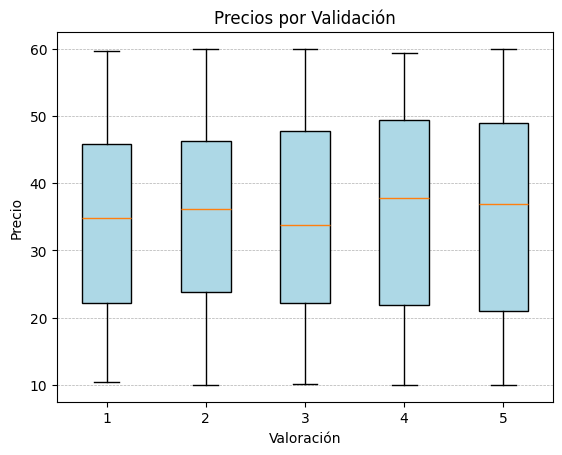

In [22]:
plt.boxplot([list(df[df['Valoración'] == i]['Precio']) for i in range(1,6)], patch_artist=True, boxprops=dict(facecolor="lightblue"))
plt.xlabel('Valoración')
plt.ylabel('Precio')
plt.title('Precios por Validación')
plt.grid(linestyle='--', linewidth=0.5, axis='y');